# GENE7 — does a graded morphology score beat the binary crispant indicator?

**The claim under test.** Crispants are mosaic F0s, so an injected clutch mixes effective nulls with
escapers. A binary label misclassifies the escapers and attenuates the contrast; a score that grades
embryos by how perturbed they *look* should partially recover the true dose and produce a larger,
more significant transcriptional effect **in the same direction**.

**How it is tested.** Three predictors, one per model, all z-scored within contrast and all carrying
one degree of freedom, so their fits are directly comparable with no penalty term:

| arm | predictor |
|---|---|
| `binary` | crispant / control indicator — the baseline to beat |
| `s` | signed distance normal to the shrunken-LDA hyperplane |
| `hinge` | `max(s − control mean, 0)` — controls collapsed, crispant gradient kept |

The hinge is the mosaic model written as a functional form: if escapers really are indistinguishable
from wildtype, their spread along `s` is noise and severity should only count above threshold.

**Counts and depth.** edgeR negative-binomial GLMs, one per cell type, with `offset = log(total
cells per embryo)` — not TMM, since TMM's "most features unchanged" assumption is shakier across
370 cell types than across 20,000 genes. Coefficients are therefore on the log-**proportion** scale.
Quasi-likelihood F-tests (`glmQLFTest`), which control type-I error better than the LRT at this n.
**FDR is applied within each contrast**, treating it as its own universe.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

HERE = Path.cwd()
sys.path.insert(0, str(HERE))

import edger_plots as ep
ep.use_house_style()
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 40)

DATA = HERE / "data" / "edger"
coefficients = pd.read_csv(DATA / "coefficients.csv")
global_stats = pd.read_csv(DATA / "global_stats.csv")
geometry     = pd.read_csv(DATA / "arm_geometry.csv")
quality      = pd.read_csv(DATA / "contrast_axis_quality.csv")
predictors   = pd.read_csv(DATA / "contrast_predictors.csv")
type_index   = pd.read_csv(DATA / "cell_type_index.csv")
status       = pd.read_csv(DATA / "contrast_status.csv")

print(f"{global_stats['contrast'].nunique()} contrasts x {global_stats['arm'].nunique()} arms")
print(f"{len(coefficients):,} cell-type coefficients")


36 contrasts x 8 arms
13,354 cell-type coefficients


## 1. The global statistic, and why it is not a Mahalanobis distance

The intent was to treat each contrast's coefficient vector as a point in ~370-D space and measure
its Mahalanobis distance from the null. **That is degenerate here, provably.**

The score for cell type *k* is `U_k = Σᵢ xᵢ(y_ki − μ⁰_ki)`, i.e. `U = R x` — *linear* in the
predictor. Permuting a z-scored `x` therefore gives `Cov(U) = R(I − 11ᵀ/n)Rᵀ`, whose rank is at most
**n − 1 ≈ 21** regardless of how many cell types there are, and regardless of how many permutations
are drawn — the rank is set by the embryo count, not by the size of the null sample. Pseudo-inverting
it yields `D² = xᵀ(I − 11ᵀ/n)x = n − 1` for *every* z-scored predictor: identical across all three
arms, carrying no information.

So the statistic used is the permutation-calibrated `T = Σₖ zₖ²`, compared against its own
permutation distribution and reported as `T_std = (T − mean_null)/sd_null`. The cross-type
dependence is absorbed by construction, because the null is generated *with* that dependence intact —
no covariance is ever estimated or inverted. A shrinkage-regularised Mahalanobis (`d_shrunk`) is
carried as a sensitivity arm.

`T_std` is scale-invariant: rescaling a predictor rescales `U` and its null SD together. The
comparison cannot be won by `s` simply having more range than a 0/1 indicator.


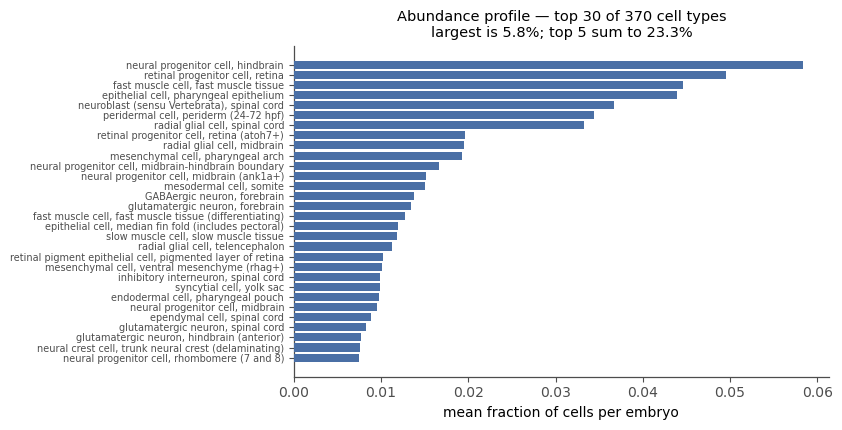

In [2]:
figure = ep.abundance_profile(type_index)


The compositional failure mode — one abundant type moving and dragging every other coefficient
negative — is not in play. The largest cell type averages 5.8% of an embryo's cells and the top five
sum to 23%, so no single type can dominate the offset.


In [3]:
dropped = status.loc[status["n_dropped"] > 0, ["contrast", "n_embryos", "n_dropped", "n_cell_types"]]
print(f"{int(status['n_dropped'].sum())} embryos had morphology but no cells in the CDS, "
      f"affecting {len(dropped)} contrasts:")
dropped.sort_values("n_dropped", ascending=False).head(12)


22 embryos had morphology but no cells in the CDS, affecting 16 contrasts:


,contrast,n_embryos,n_dropped,n_cell_types
12,ctcf vs ctrl | 24C | 24hpf,20,3,43
22,ctcf vs ctrl | 35C | 30hpf,19,3,45
30,"wfs1a,wfs1b vs ctrl | 34C | 24hpf",22,2,53
13,ctcf vs ctrl | 24C | 30hpf,22,2,31
10,atf6 vs ctrl | 35C | 30hpf,20,1,56
8,atf6 vs ctrl | 34C | 36hpf,22,1,85
2,atf6 vs ctrl | 24C | 36hpf,23,1,43
7,atf6 vs ctrl | 34C | 30hpf,23,1,54
16,ctcf vs ctrl | 28C | 30hpf,22,1,41
11,atf6 vs ctrl | 35C | 36hpf,23,1,76


## 2. Head-to-head

Each line is one contrast, tracked across the three predictors. Within-contrast comparison is the
only meaningful one — absolute levels vary enormously between contrasts.


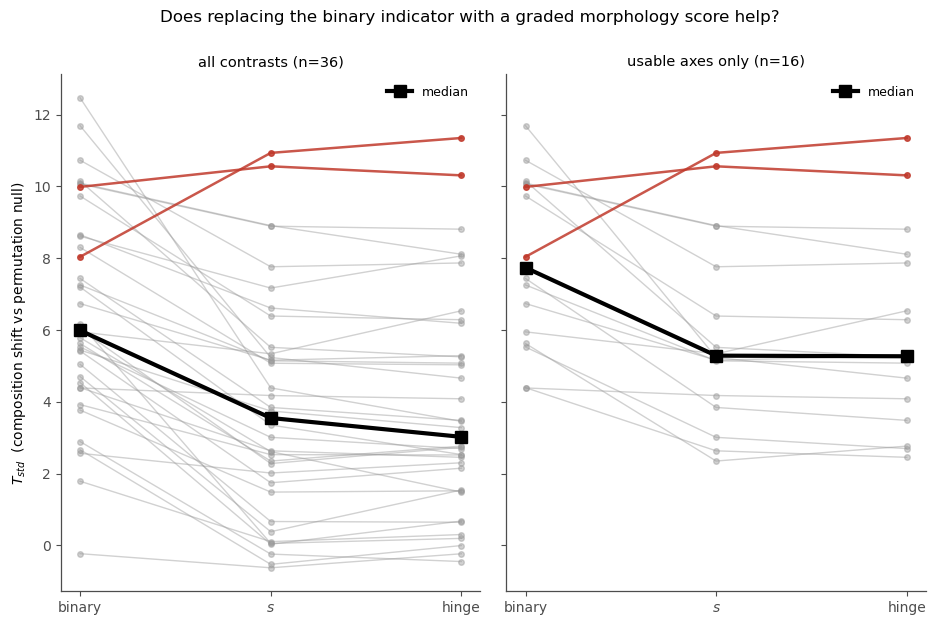

In [4]:
figure = ep.head_to_head(global_stats, quality)


In [5]:
wide = global_stats.pivot(index="contrast", columns="arm", values="t_std").join(
    quality.set_index("contrast")[["loo_auc", "usable", "target", "temperature"]])

rows = []
for label, subset in (("all 36", wide), ("usable axes (16)", wide[wide["usable"]])):
    for arm in ("s_z", "hinge_z"):
        delta = (subset[arm] - subset["binary_z"]).dropna()
        rows.append({
            "set": label, "arm": arm,
            "wins": int((delta > 0).sum()), "n": len(delta),
            "median_delta": delta.median(),
            "wilcoxon_p": stats.wilcoxon(delta)[1],
        })
pd.DataFrame(rows).round(4)


,set,arm,wins,n,median_delta,wilcoxon_p
0,all 36,s_z,2,36,-2.7424,0.0000
1,all 36,hinge_z,3,36,-2.7497,0.0000
2,usable axes (16),s_z,2,16,-1.9365,0.0021
3,usable axes (16),hinge_z,3,16,-2.0797,0.0063


**The hypothesis fails, and it fails cleanly.** The binary indicator produces a larger composition
shift than the graded score in 34 of 36 contrasts, and restricting to the 16 contrasts whose
morphology axis actually passed its quality gates does not rescue it — 14 of 16 still favour the
binary label. The hinge, which was supposed to fix exactly the dilution problem by collapsing the
controls, does no better.

This is a real negative result rather than an underpowered one: the effect is consistent in
direction across contrasts and the Wilcoxon p-values are small.


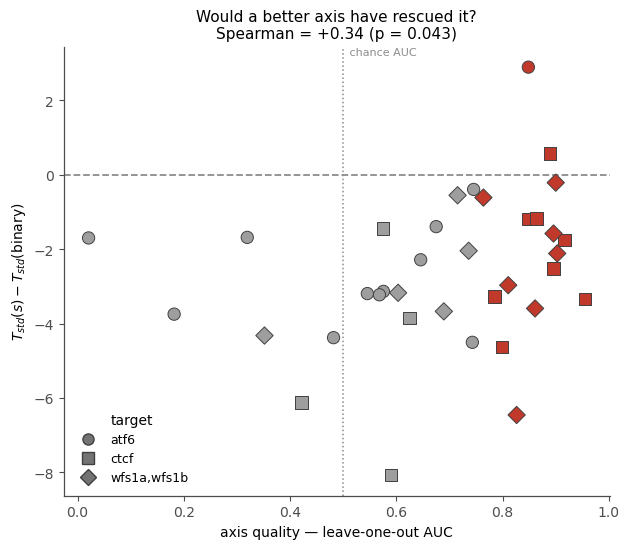

In [6]:
figure = ep.quality_versus_gain(global_stats, quality)


The obvious rescue — "the axes were just bad" — does not hold either. There is a weak positive trend
(better axes lose by less) but it is far from significant and nowhere near large enough to cross
zero. Even the contrasts with LOO-AUC above 0.9 lose to the binary indicator.

## 3. Direction: is `s` finding something different, or the same thing weaker?

This is the diagnostic part. The original geometric claim was *same direction, bigger magnitude*.


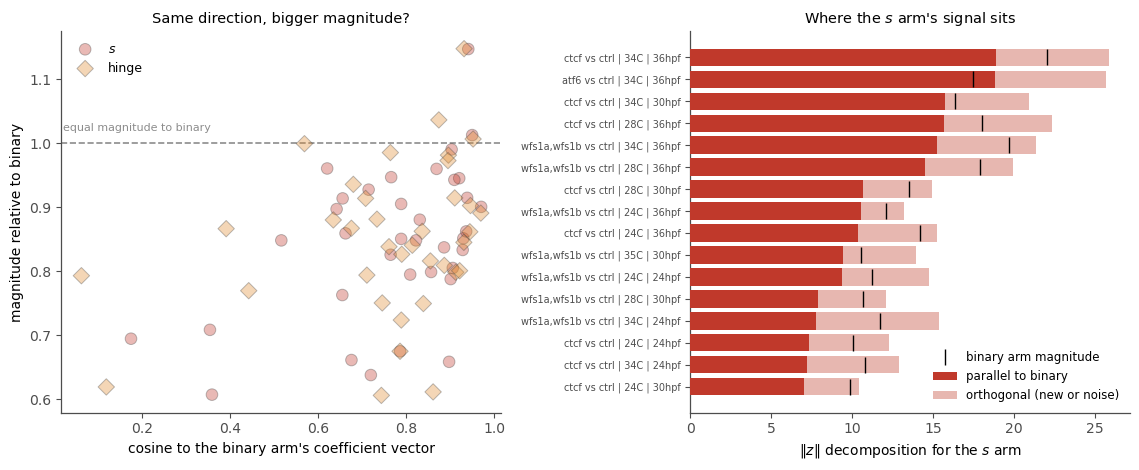

In [7]:
figure = ep.geometry_plot(geometry, quality)


In [8]:
merged = geometry.merge(quality[["contrast", "usable"]], on="contrast")
summary = []
for arm in ("s_z", "hinge_z"):
    block = merged[(merged["arm"] == arm) & merged["usable"]]
    summary.append({
        "arm": arm,
        "median_cosine_to_binary": block["cosine_to_binary"].median(),
        "median_magnitude_ratio": (block["norm"] / block["norm_binary"]).median(),
        "median_orthogonal_fraction": (block["orthogonal_component"] / block["norm"]).median(),
    })
pd.DataFrame(summary).round(3)


,arm,median_cosine_to_binary,median_magnitude_ratio,median_orthogonal_fraction
0,s_z,0.913,0.891,0.408
1,hinge_z,0.911,0.877,0.412


**Same direction, smaller magnitude.** Cosine to the binary arm's coefficient vector is 0.91 — the
morphology score is emphatically *not* finding a different transcriptional axis. But its magnitude
is 0.89 of the binary arm's, with 41% of its length lying orthogonal to the binary contrast.

The interpretation that fits all of this: the graded score is an **attenuated, noisier proxy for
group membership**. The within-crispant morphological gradient is real — visible in the image strips
and reproducible under resampling — but as a predictor it blurs a clean group contrast rather than
sharpening it. §3b measures directly how much it does add.

## 3b. Does the within-crispant gradient add anything *beyond* the label?

Everything above asked whether `s` can **replace** the binary indicator. It can't. The different
question is whether the graded part adds information **on top of** it.

`s` is split into the part that *is* the group label and the part that isn't: `s_within = s − (own
group's mean of s)`. That column has zero mean inside both groups, so it is exactly orthogonal to
the binary indicator — verified at |corr| < 1e-16 in the export. Without that centering the two
predictors would be near-collinear (`s` was built to separate the groups) and both coefficients
would carry inflated standard errors, likely leaving neither significant and telling us nothing.

The slopes are estimated **separately per group** rather than pooled, which buys a built-in negative
control. Control embryos also vary along `s`; if that variation is measurement noise the control
slope should be zero. If instead both slopes came out similar and non-zero, that would be the
signature of a shared nuisance — developmental stage being the obvious suspect, since morphology
encodes it strongly and it drives composition hard.


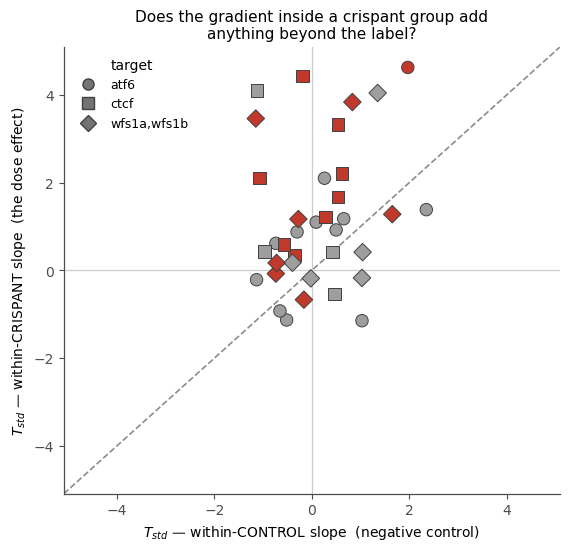

In [9]:
figure = ep.within_slope_plot(global_stats, quality)


In [10]:
rows = []
for arm in ("s_within_crispant", "s_within_control"):
    block = global_stats[global_stats["arm"] == arm]
    rows.append({
        "arm": arm, "n_contrasts": len(block),
        "median_T_std": block["t_std"].median(),
        "p_global_lt_05": int((block["p_global"] < 0.05).sum()),
        "median_hits_q10": block["n_hits_q10"].median(),
        "max_hits_q10": block["n_hits_q10"].max(),
    })
pd.DataFrame(rows).round(3)


,arm,n_contrasts,median_T_std,p_global_lt_05,median_hits_q10,max_hits_q10
0,s_within_crispant,36,0.900,9,0.0,31
1,s_within_control,36,0.035,2,0.0,1


In [11]:
from scipy.stats import binomtest, mannwhitneyu
rows = []
for arm in ("s_within_crispant", "s_within_control"):
    b = global_stats[global_stats["arm"] == arm]
    k, n = int((b["p_global"] < 0.05).sum()), len(b)
    rows.append({"arm": arm, "hits_p<0.05": f"{k}/{n}", "expected_by_chance": round(0.05 * n, 1),
                 "binomial_p": binomtest(k, n, 0.05, alternative="greater").pvalue})
display(pd.DataFrame(rows))

paired = global_stats.pivot(index="contrast", columns="arm", values="p_global")
print(f"paired Wilcoxon on the two slopes' p-values: "
      f"p = {stats.wilcoxon(paired['s_within_crispant'], paired['s_within_control'])[1]:.4f}")
print(f"crispant slope more significant than its own control in "
      f"{int((paired['s_within_crispant'] < paired['s_within_control']).sum())}/{len(paired)}")


,arm,hits_p<0.05,expected_by_chance,binomial_p
0,s_within_crispant,9/36,1.8,0.000053
1,s_within_control,2/36,1.8,0.543271


paired Wilcoxon on the two slopes' p-values: p = 0.0026
crispant slope more significant than its own control in 26/36


**A real positive with a clean negative control — and the right frame is the chance rate, not the
median.** Nine to ten of 36 contrasts clear p<0.05 where chance would give 1.8: a binomial p around
1e-5. The within-control slope sits at the chance rate exactly. Paired across contrasts the crispant
slope is more significant than its own negative control in 26/36, Wilcoxon p = 0.002.

So the confound worry does **not** materialise — control-side variation along `s` behaves like noise,
and what the crispant slope picks up is not developmental stage leaking in through both groups.

The reason to be careful about how this gets described: median hits at q<0.10 is **zero cell types**.
That is a statement about *per-cell-type* power at n≈11, not about absence of signal. A modest effect
spread thinly across many cell types produces exactly this — a strong global test with no individual
survivors. Reading the medians alone (+0.90 vs +0.08) understates it; reading the chance rate does
not.

## 3c. Are wildtype-looking crispants actually unperturbed?

The three-level fit, and the part that explains the negative result. "Escaper" is a crispant falling
inside the entire observed control range — deliberately the most permissive definition, because the
category is thin.

**Worth stating why it is thin, since it is structural rather than a threshold artifact.** A contrast
has a trustworthy axis precisely when the groups separate cleanly, which is when few crispants land
in control territory. Escaper-rich and axis-trustworthy are in direct tension. Splitting at the
control *mean* left the median contrast with exactly one escaper; even at the control *maximum* only
21/36 contrasts have four or more in both cells. The rest are marked not-estimable rather than
allowed to emit noisy coefficients off 2–3 embryos.

Note what this design avoids: **dropping** the wildtype-looking crispants would delete observations
conditional on a label-derived quantity — removing precisely the crispants nearest the decision
boundary, whose transcriptomes are presumably also the most control-like — and would mechanically
widen the group gap. Every embryo is kept here.


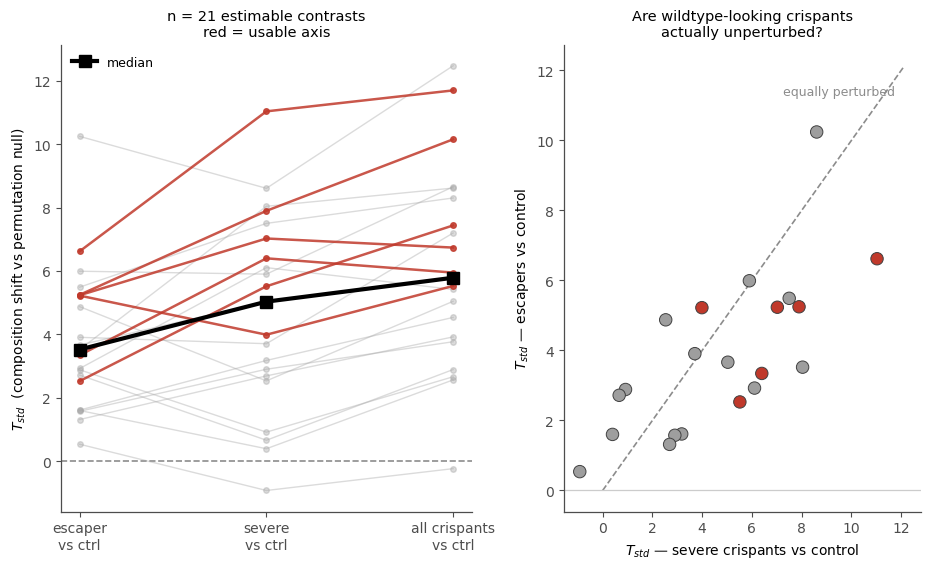

In [12]:
figure = ep.three_level_plot(global_stats, quality)


In [13]:
rows = []
for arm in ("escaper_vs_control", "severe_vs_control", "severe_vs_escaper", "binary_z"):
    block = global_stats[global_stats["arm"] == arm]
    rows.append({
        "arm": arm, "n_contrasts": len(block),
        "median_T_std": block["t_std"].median(),
        "p_global_lt_05": int((block["p_global"] < 0.05).sum()),
        "median_hits_q10": block["n_hits_q10"].median(),
    })
display(pd.DataFrame(rows).round(3))
print(status[["contrast", "n_control", "n_escaper", "n_severe", "three_level_estimable"]]
      .sort_values("n_escaper").head(8).to_string(index=False))


,arm,n_contrasts,median_T_std,p_global_lt_05,median_hits_q10
0,escaper_vs_control,27,3.909,21,6.0
1,severe_vs_control,30,6.002,26,13.0
2,severe_vs_escaper,21,0.708,4,0.0
3,binary_z,36,5.988,34,11.0


                         contrast  n_control  n_escaper  n_severe  three_level_estimable
       ctcf vs ctrl | 24C | 24hpf         12          1         7                  False
       ctcf vs ctrl | 28C | 30hpf         12          1         9                  False
       ctcf vs ctrl | 34C | 36hpf         12          1        10                  False
wfs1a,wfs1b vs ctrl | 35C | 30hpf          9          1        11                  False
       ctcf vs ctrl | 28C | 36hpf         11          3         9                  False
       ctcf vs ctrl | 34C | 30hpf         12          3         8                  False
wfs1a,wfs1b vs ctrl | 24C | 36hpf         12          3         9                  False
       atf6 vs ctrl | 34C | 36hpf         12          3         7                  False


**Escapers are not escapers in any molecular sense.** Morphologically normal-looking crispants show a
median `T_std` of +3.9, significant in 21 of 27 estimable contrasts, with a median of 6 cell types
passing q<0.10. An embryo that looks entirely wildtype carries roughly 70% of the composition shift
of an obviously deformed one.

**Does severity stratify? Two ways of asking, one of which is much better.** Comparing
`escaper_vs_control` against `severe_vs_control` means comparing two test statistics from two models
on two different embryo subsets — weak, and with no p-value of its own. It must also be **paired**
over the contrasts where both are estimable; the unpaired medians in the table mix different contrast
sets and overstate the gap.

The direct contrast — severe against escaper, controls dropped — is the right instrument. Both groups
are injected, so injection efficiency, handling and batch cancel, and the permutation null becomes
exactly "morphological class among crispants is arbitrary".


In [14]:
paired = (global_stats[global_stats["arm"] == "escaper_vs_control"][["contrast", "t_std"]]
          .merge(global_stats[global_stats["arm"] == "severe_vs_control"][["contrast", "t_std"]],
                 on="contrast", suffixes=("_escaper", "_severe")))
gap = paired["t_std_severe"] - paired["t_std_escaper"]
print(f"INDIRECT (paired severe - escaper, each vs control), n={len(gap)}")
print(f"  median gap {gap.median():+.2f} | severe larger in {int((gap>0).sum())}/{len(gap)} "
      f"| Wilcoxon p = {stats.wilcoxon(gap)[1]:.4f}")

direct = global_stats[global_stats["arm"] == "severe_vs_escaper"]
k, n = int((direct["p_global"] < 0.05).sum()), len(direct)
print(f"\nDIRECT (severe vs escaper), n={n}")
print(f"  {k}/{n} at p<0.05 | chance {0.05*n:.1f} "
      f"| binomial p = {binomtest(k, n, 0.05, alternative='greater').pvalue:.4f}")
print(f"  median T_std {direct['t_std'].median():+.2f} | median hits q<0.10 "
      f"{direct['n_hits_q10'].median():.0f}")

same = global_stats[(global_stats["arm"] == "s_within_crispant")
                    & global_stats["contrast"].isin(direct["contrast"])]
print(f"\nCONTINUOUS gradient on those same {len(same)} contrasts: "
      f"{int((same['p_global']<0.05).sum())}/{len(same)} at p<0.05")


INDIRECT (paired severe - escaper, each vs control), n=21
  median gap +1.37 | severe larger in 12/21 | Wilcoxon p = 0.1111

DIRECT (severe vs escaper), n=21
  4/21 at p<0.05 | chance 1.1 | binomial p = 0.0189
  median T_std +0.71 | median hits q<0.10 0

CONTINUOUS gradient on those same 21 contrasts: 4/21 at p<0.05


**Severity does stratify, weakly.** The direct contrast clears p<0.05 in 4 of 21 contrasts against a
chance expectation of 1.1 — **binomial p = 0.019**. So morphologically severe crispants really are
transcriptionally different from wildtype-looking ones. But the effect is small: median `T_std` +0.71
and **zero** cell types surviving FDR in the median contrast. The indirect paired comparison stays
non-significant (median gap +1.37, 12/21, Wilcoxon p = 0.11), which is consistent — it is simply the
weaker way to ask.

**A prediction that did not pan out, worth recording.** Going in, the expectation was that
dichotomising a continuous gradient into two bins of ~5 would be throwing away most of the power, and
that the continuous within-crispant slope would substantially outperform the binary split. On these
same 21 contrasts they are **identical — 4/21 each**. Binning cost nothing detectable here, so the
weakness of the stratification result is not an artifact of how the variable was coarsened.

Taken together with §3b, the picture is that morphology carries real but *diffuse and modest*
information about molecular state: enough to beat chance several ways over, not enough to move
individual cell types, and not enough to substitute for knowing which embryos were injected.


## 3d. The fairer question: *when* morphology is informative, does it buy power?

"Does morphology help?" averaged over all 36 contrasts is arguably the wrong question, and §2 answers
it in a way heavily weighted by contrasts where there was no morphological phenotype to exploit in
the first place. The conditional question is the one worth asking: **where crispants are clearly
distinguishable morphologically, does the graded information buy statistical power?**

Every panel below carries the **within-control slope** as a matched negative control. That is what
distinguishes a real morphology-to-molecular relationship from "some contrasts are simply cleaner
than others" — a generic quality effect would lift both slopes together.


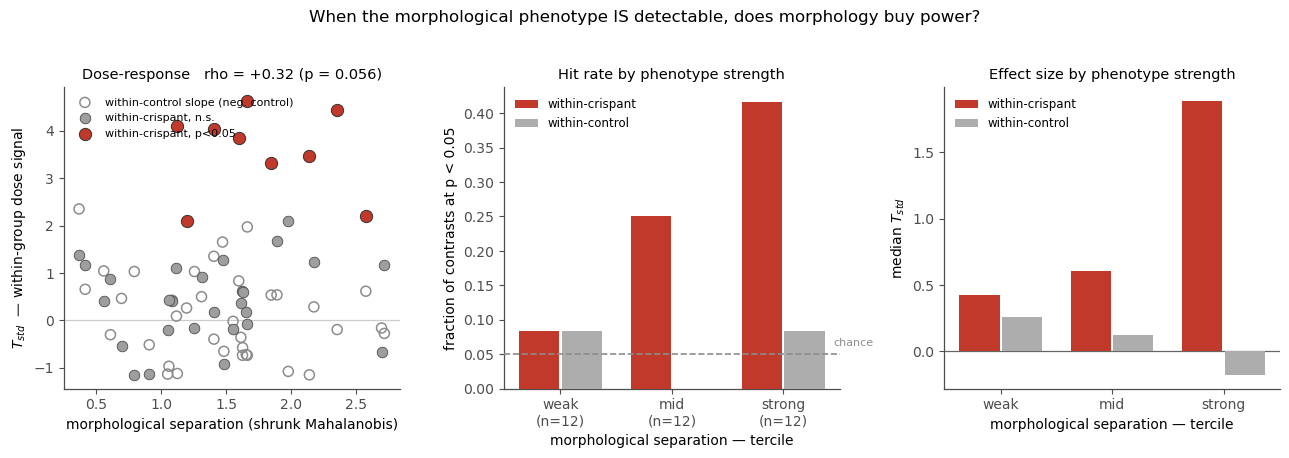

In [15]:
figure, tercile_table = ep.power_vs_phenotype(global_stats, quality, metric="separation")


In [16]:
display(tercile_table.round(3))

rows = []
for name, arm in (("within-crispant", "s_within_crispant"),
                  ("within-control (neg. ctrl)", "s_within_control")):
    d = (global_stats[global_stats["arm"] == arm].set_index("contrast")[["p_global"]]
         .join(quality.set_index("contrast")[["usable"]]))
    a = int((d["usable"] & (d["p_global"] < 0.05)).sum()); b = int(d["usable"].sum()) - a
    c = int((~d["usable"] & (d["p_global"] < 0.05)).sum()); e = int((~d["usable"]).sum()) - c
    odds, p = stats.fisher_exact([[a, b], [c, e]], alternative="greater")
    rows.append({"slope": name, "usable_axis": f"{a}/{a+b}", "weak_axis": f"{c}/{c+e}",
                 "odds_ratio": odds, "fisher_p": p})
pd.DataFrame(rows).round(4)


,crispant,control,median_t_crispant,median_t_control,n
tercile,,,,,
weak,0.083,0.083,0.425,0.257,12.0
mid,0.250,0.000,0.604,0.120,12.0
strong,0.417,0.083,1.885,-0.177,12.0


,slope,usable_axis,weak_axis,odds_ratio,fisher_p
0,within-crispant,6/16,3/20,3.4000,0.1229
1,within-control (neg. ctrl),1/16,1/20,1.2667,0.6984


And the same relationship stated directly in terms of *significance* rather than effect size, since
that is the quantity the claim is about. Higher is more significant; the dashed line is p = 0.05.


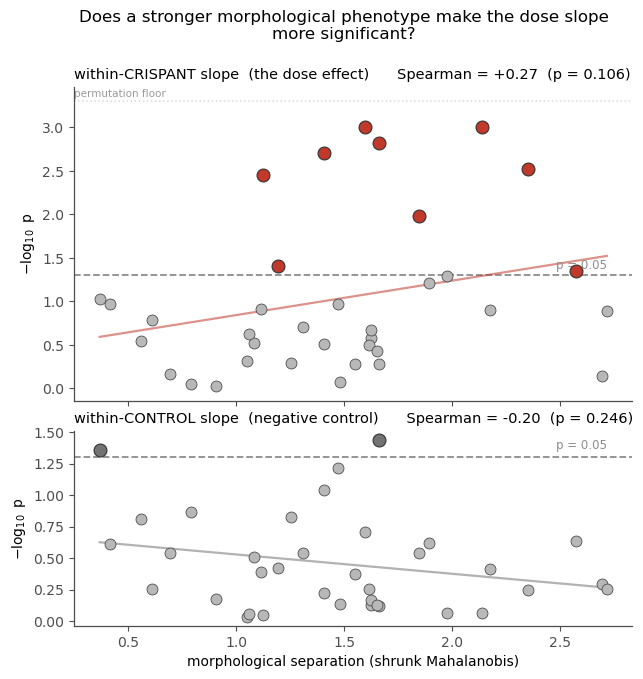

In [17]:
figure = ep.significance_vs_phenotype(global_stats, quality, metric="separation")


In [18]:
rows = []
for arm, name in (("s_within_crispant", "within-crispant"),
                  ("s_within_control", "within-control (neg. ctrl)")):
    d = (global_stats[global_stats["arm"] == arm].set_index("contrast")
         .join(quality.set_index("contrast")[["separation"]]))
    d["tercile"] = pd.qcut(d["separation"], 3, labels=[0, 1, 2]).astype(int)
    hits = d.groupby("tercile")["p_global"].apply(lambda x: (x < 0.05).sum()).to_numpy()
    sizes = d.groupby("tercile").size().to_numpy()
    # Cochran-Armitage test for trend in proportions across ordered terciles.
    t = np.array([0, 1, 2]); N = sizes.sum(); R = hits.sum()
    var = R * (N - R) * (N * (t**2 * sizes).sum() - ((t * sizes).sum())**2) / N
    z = (t * (hits * N - sizes * R)).sum() / np.sqrt(var) if var > 0 else np.nan
    rows.append({
        "slope": name,
        "rho_effect_size": stats.spearmanr(d["separation"], d["t_std"]).statistic,
        "p_effect_size": stats.spearmanr(d["separation"], d["t_std"]).pvalue,
        "rho_significance": stats.spearmanr(d["separation"], -np.log10(d["p_global"])).statistic,
        "p_significance": stats.spearmanr(d["separation"], -np.log10(d["p_global"])).pvalue,
        "hits_by_tercile": "/".join(map(str, hits)),
        "trend_z": z, "trend_p": 2 * stats.norm.sf(abs(z)),
    })
pd.DataFrame(rows).round(3)


,slope,rho_effect_size,p_effect_size,rho_significance,p_significance,hits_by_tercile,trend_z,trend_p
0,within-crispant,0.321,0.056,0.274,0.106,1/3/5,1.886,0.059
1,within-control (neg. ctrl),-0.214,0.210,-0.198,0.246,1/0/1,0.000,1.000


**Directionally yes, but marginal — and worth stating carefully, because how you slice it changes
how strong it looks.** Three ways of asking the same question:

| framing | within-crispant | within-control (neg. ctrl) |
|---|---|---|
| separation vs effect size (`T_std`) | rho +0.32, **p = 0.056** | −0.21, p = 0.21 |
| separation vs significance (−log₁₀p) | rho +0.27, **p = 0.106** | −0.20, p = 0.25 |
| hit rate by tercile | 1/12 → 3/12 → 5/12, **trend p = 0.059** | 1/12 → 0/12 → 1/12, trend p = 1.00 |

All three point the same way and **none reaches p < 0.05.** The tercile table is the most flattering
presentation — "five times the hit rate" sounds decisive but rests on 1 versus 5 events, and the
formal trend test on it lands at 0.059, not below. Quoting the tercile framing alone would overstate
what is here.

What genuinely strengthens it is the negative control: the within-control slope is flat-to-negative
on all three, and perfectly flat on the tercile trend (z = 0.00). Same embryos, same model, same
permutation machinery — only the group changed. So the pattern is specific to the crispant side
rather than a generic "cleaner contrasts give cleaner everything" effect, which is the alternative
that would otherwise be hard to rule out.

**Honest summary: suggestive, consistent across three framings and cleanly absent in the matched
control, but not established at n = 36 contrasts.** The right claim is that where there is a real
morphological phenotype the dose signal is *plausibly* stronger, not that it demonstrably is. The
binding constraint is the number of contrasts, not the number of embryos — which is worth knowing,
because it is fixable by adding perturbations or conditions rather than by sequencing more deeply.

One caveat that survives regardless: contrasts with strong morphological phenotypes are plausibly the
ones where the perturbation *worked better*. Morphology and transcriptome would then be
co-symptomatic of injection efficacy rather than one being informative about the other, and every
panel above would look identical either way. Distinguishing them needs an independent measure of
editing efficiency.

## 4. Per-contrast detail

Every contrast, with its axis on the left and what the regressions did with it on the right. The dot
plot is the thing to read first: separation, overlap, and the within-crispant spread the graded score
was supposed to be exploiting.


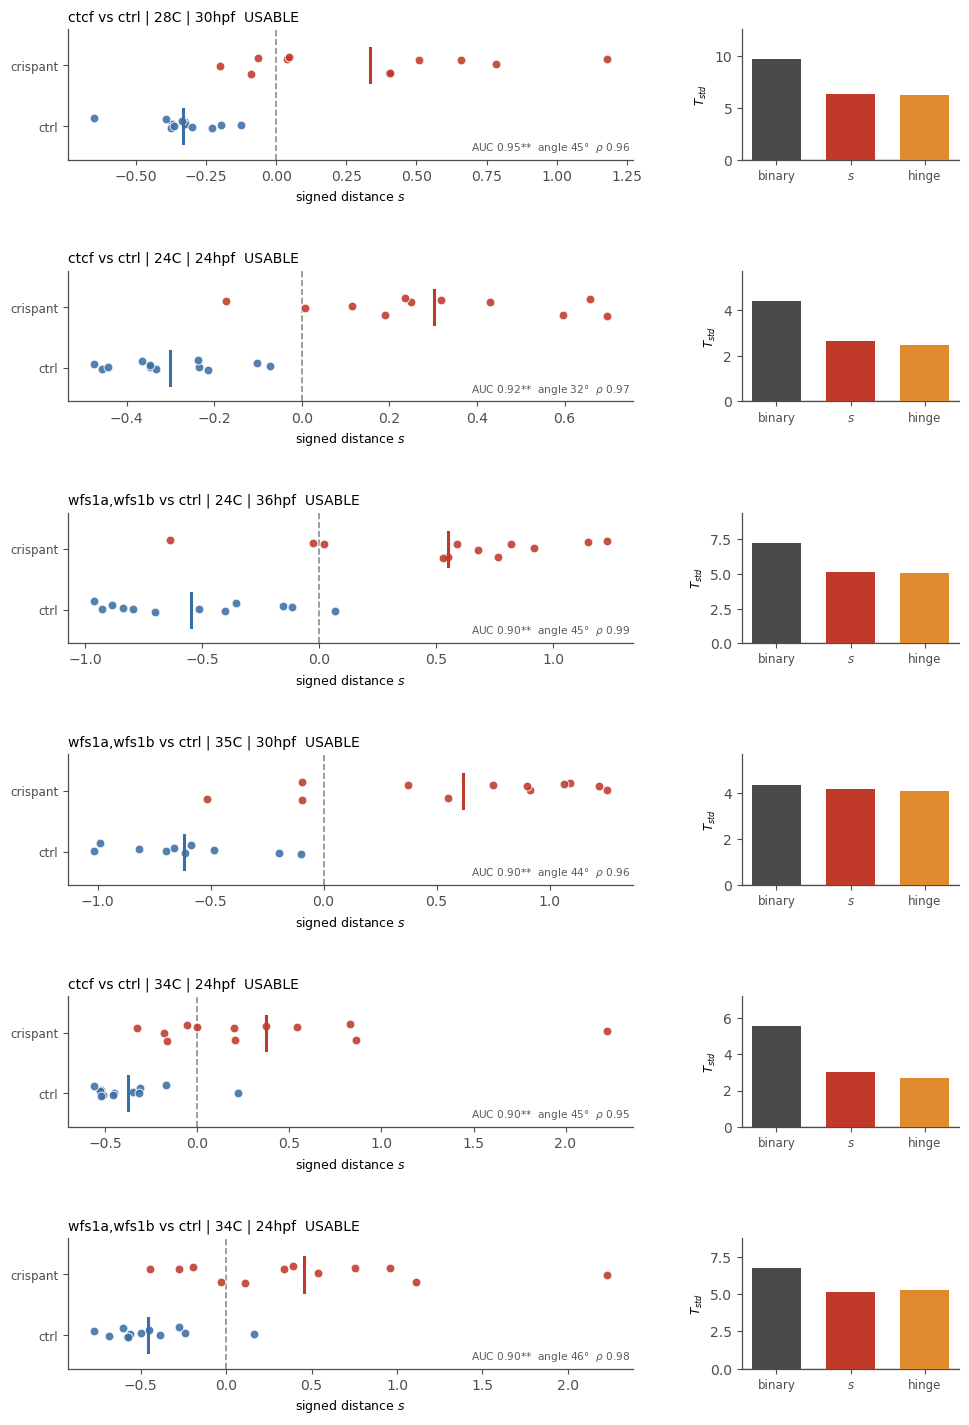

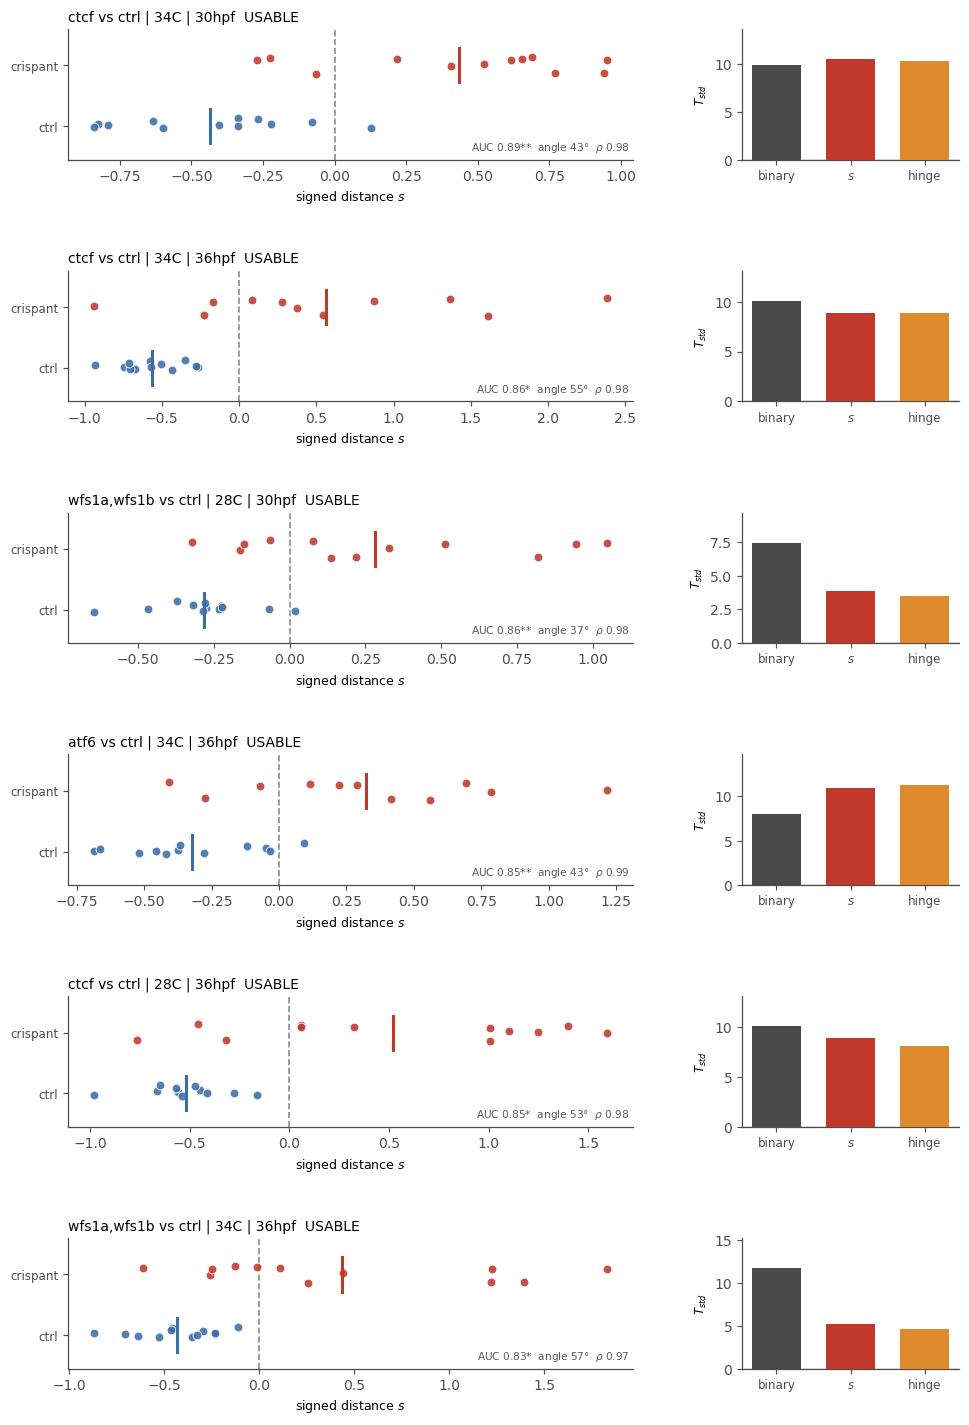

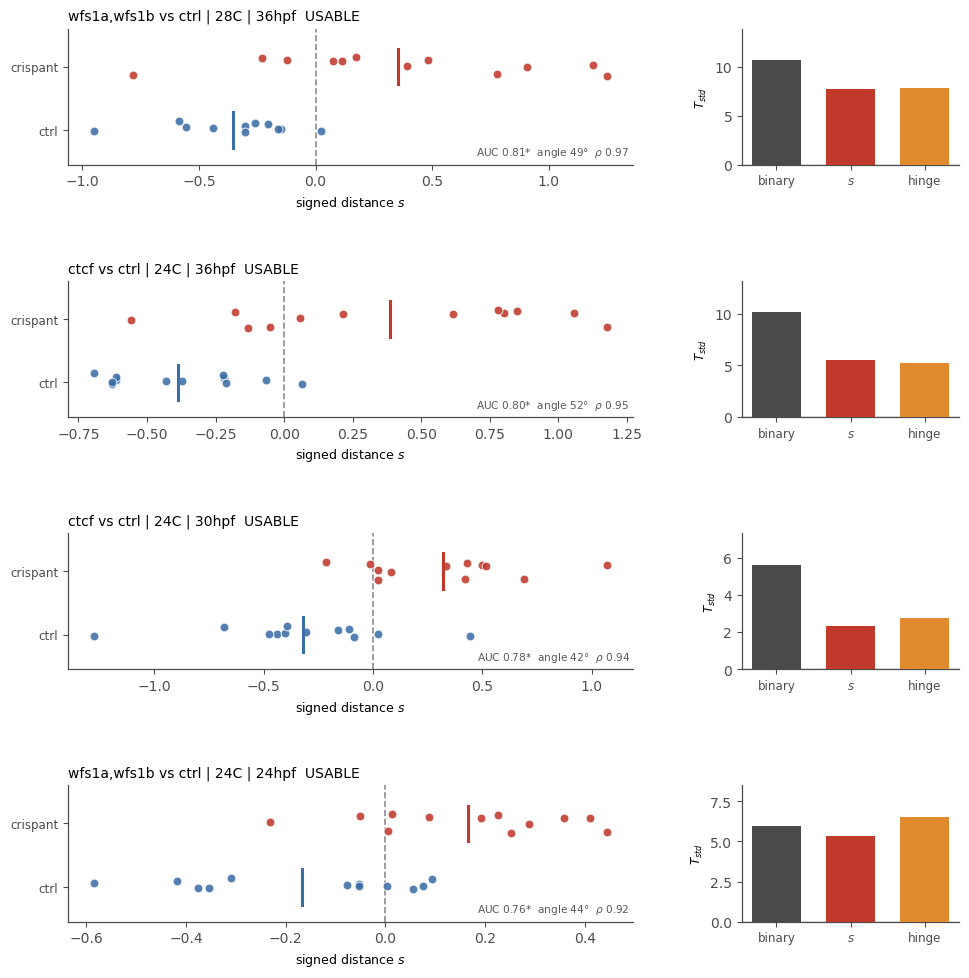

In [19]:
usable_contrasts = (
    quality.loc[quality["usable"]].sort_values("loo_auc", ascending=False)["contrast"].tolist()
)
from IPython.display import display
import matplotlib.pyplot as plt
for figure in ep.contrast_grid(predictors, quality, global_stats, usable_contrasts, per_page=6):
    display(figure); plt.close(figure)


And the contrasts whose axis failed its gates, for comparison — controls and crispants interleaved,
and no consistent advantage to any arm.


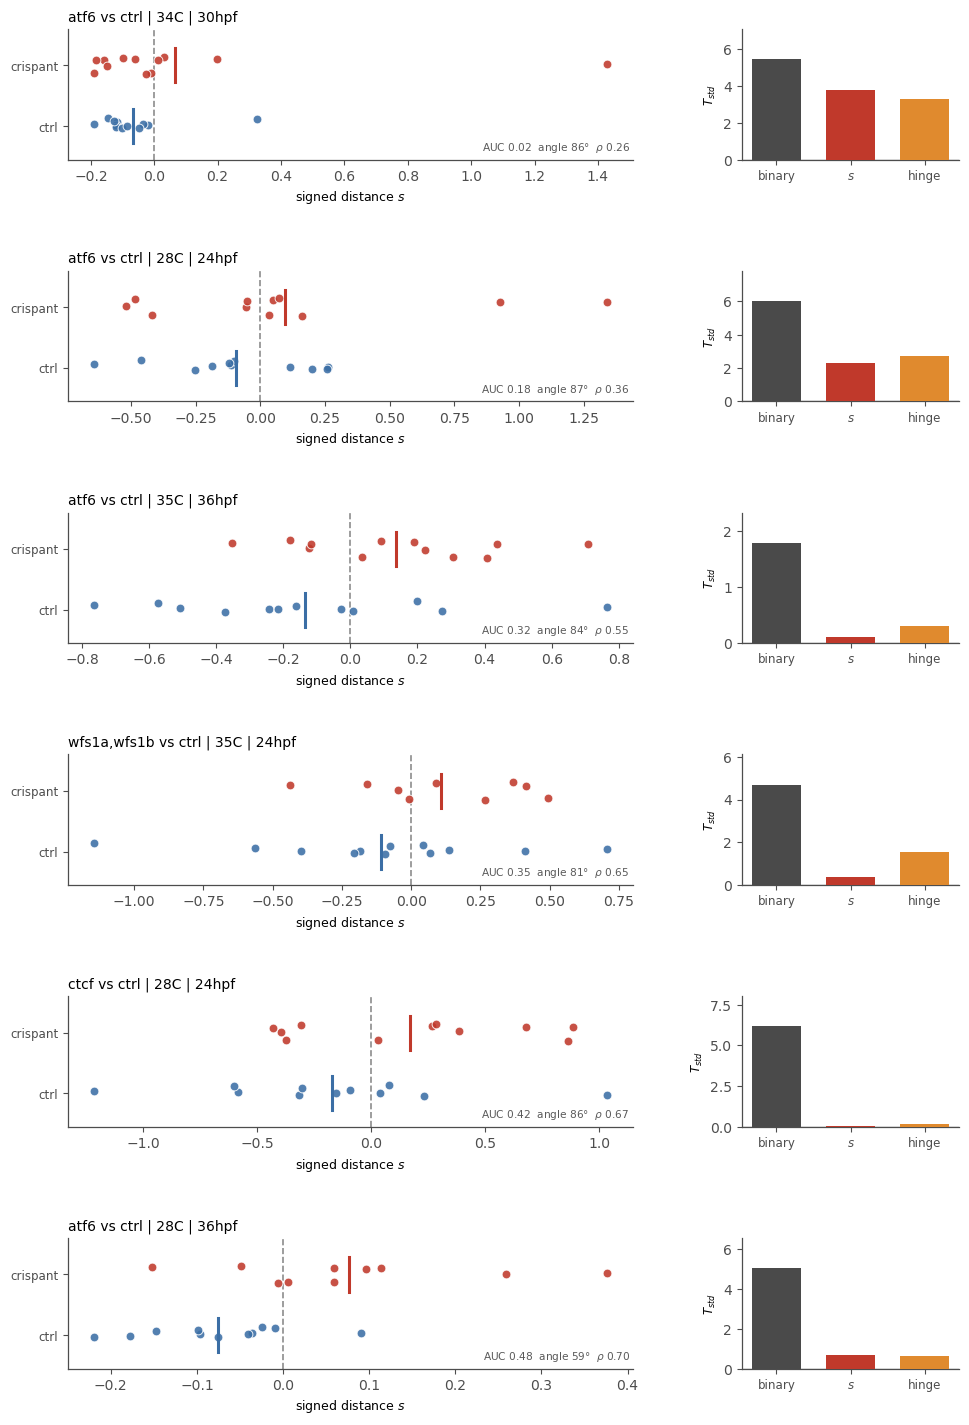

In [20]:
failing = (
    quality.loc[~quality["usable"]].sort_values("loo_auc")["contrast"].head(6).tolist()
)
for figure in ep.contrast_grid(predictors, quality, global_stats, failing, per_page=6):
    display(figure); plt.close(figure)


## 5. Cell-type level

The contrast-level statistic is a summary; this is what it summarises. Compression toward the
horizontal is the attenuation showing up per cell type.


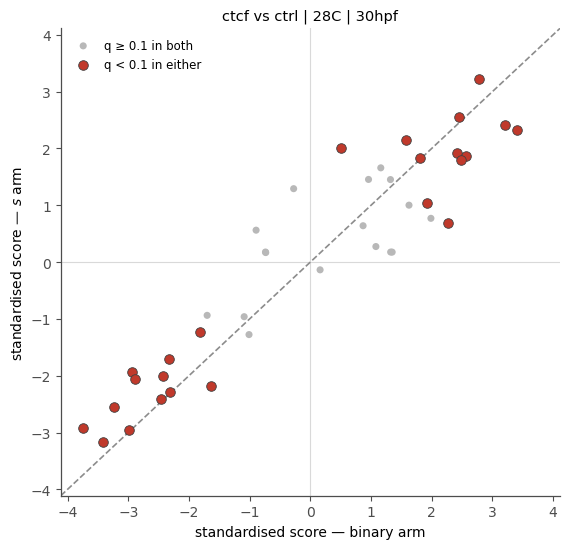

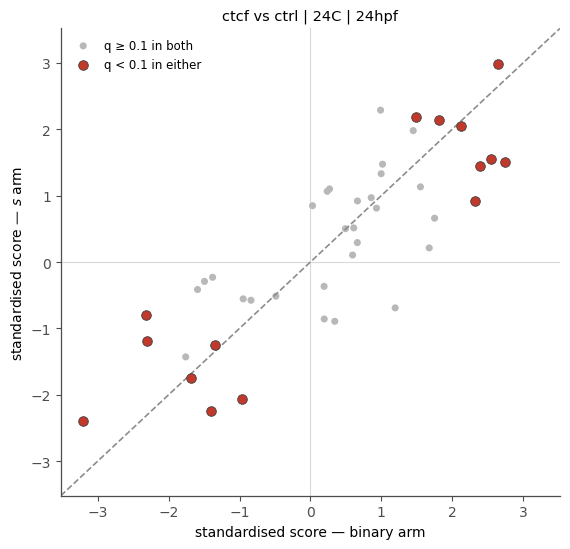

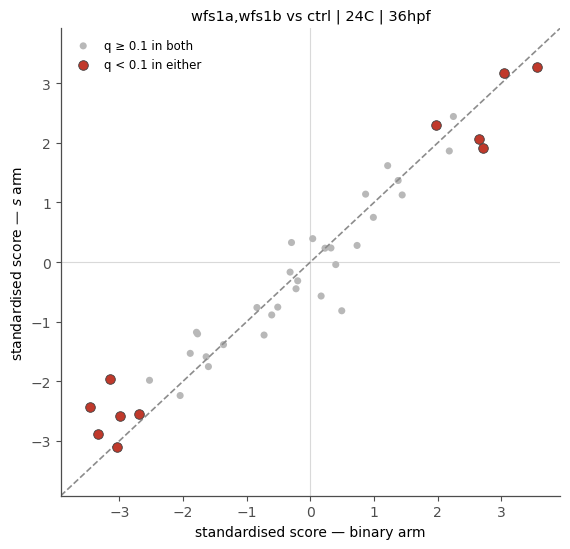

In [21]:
for contrast in usable_contrasts[:3]:
    figure = ep.cell_type_scatter(coefficients, contrast)
    display(figure); plt.close(figure)


In [22]:
hits = global_stats.pivot(index="contrast", columns="arm", values="n_hits_q10").join(
    quality.set_index("contrast")["usable"])
print("cell types at q<0.10 within contrast (median):")
print(hits[["binary_z", "s_z", "hinge_z"]].median().round(1).to_string())
print("\nusable axes only:")
print(hits[hits["usable"]][["binary_z", "s_z", "hinge_z"]].median().round(1).to_string())


cell types at q<0.10 within contrast (median):
binary_z    11.0
s_z          8.5
hinge_z      7.5

usable axes only:
binary_z    15.5
s_z         15.0
hinge_z     16.0


## 6. Readout

| question | answer |
|---|---|
| Does `s` beat the binary indicator? | **No** — binary wins 34/36 (14/16 usable), median ΔT_std −2.7 |
| Is `s` finding a *different* signal? | No — cosine 0.91, magnitude 0.89. Same direction, weaker |
| Would a better axis rescue it? | No — Spearman +0.26, p = 0.12 |
| Does the within-crispant gradient add anything beyond the label? | **Yes, weakly** — 9–10/36 at p<0.05 vs 1.8 by chance, binomial p ≈ 1e-5. But 0 cell types at q<0.10 |
| Is the negative control clean? | Yes — within-control slope at exactly the chance rate. Not a stage artifact |
| Are wildtype-looking crispants unperturbed? | **No** — T_std +3.9, significant in 21/27, median 6 hits |
| Does severity stratify molecular state? | **Yes, weakly** — direct contrast 4/21 vs 1.1 by chance, binomial p = 0.019 |
| Does axis quality predict transcriptional strength? | Yes — rho +0.34 to +0.49 across four metrics, all p<0.05 |
| **When the phenotype IS detectable, does morphology buy power?** | **Suggestive, not established** — three framings all positive (p = 0.056 / 0.106 / 0.059), none below 0.05; negative control flat on all three |

**Two findings that must both be held at once.** Morphology carries real information about molecular
state — the within-crispant gradient beats chance by ~5×, the direct severity contrast beats chance,
and every axis-quality metric correlates with transcriptional effect size while the matched negative
control does not. And morphology still does **not** beat the group label as a replacement predictor:
that result is large, consistent, and robust to restricting on axis quality.

Those are compatible because the information morphology adds is *diffuse and modest* — enough to
clear a global permutation test several ways over, not enough to move a single cell type past FDR,
and far less than simply knowing which embryos were injected. The mosaic-dose premise needed
morphologically normal crispants to be near-unperturbed so that appearance would recover dose. §3c
shows they carry ~70% of the severe group's effect. That single fact explains the attenuation in §2
and the 0.91 cosine in §3: same signal, blurred.

**One confound these data cannot exclude.** Contrasts with a strong morphological phenotype may
simply be ones where the perturbation *worked better*, making morphology and transcriptome
co-symptomatic of injection efficacy rather than one informative about the other. The within-crispant
slope is somewhat more resistant, being conditioned on the label, but a more efficacious perturbation
would also generate more spread in true dose. Not resolvable here.

**Caveats carried forward.** Cell-type proportions are compositional, so a real change in one type
forces others down and independent per-type tests will show reciprocal hits — the abundance profile
says this is mild here (largest type 5.8%), not absent. 18 embryos with morphology had no cells in
the CDS, thinning some contrasts by up to 3; §1 lists which. And the three-level fit is estimable in
only 21/36 contrasts, for the structural reason given in §3c rather than by accident.
